# BERT 일반화 실험 결과 분석

RunPod GPU 클라우드에서 실행한 KLUE-BERT 일반화 실험 결과를 통합하고 분석합니다.

## RunPod 실험 결과 통합
- RunPod은 GPU 클라우드 플랫폼으로, 4~5개의 독립 Pod(GPU 서버)에서 실험을 병렬 실행했습니다.
- 각 Pod의 결과 CSV를 여기서 통합하여 종합 분석합니다.

## 실험 구성
- **Part 1**: 문항 조합 실험 (254개 조합)
  - 8개 문항(Q1~Q8) 중 k개(1~7)를 선택하여 학습 → 나머지로 테스트
  - Pod 1~4에서 bin-packing 방식으로 분배 실행
- **Part 2**: 학생 분할 실험 (15개 분할)
  - 학생 비율(80:20~40:60) × 3 seed = 15개 실험
  - Pod 5에서 실행
- **모델**: KLUE-BERT (klue/bert-base) — 한국어 특화 사전학습 모델
- **방법론**: Stratified 10-Fold CV + 전체 데이터 재학습 + Test 평가

## 분석 목적
1. 최소 몇 개 문항의 피드백 데이터가 있어야 일반화가 가능한지
2. 같은 시험지(Form) 내 문항 vs 다른 시험지 문항의 전이 효과
3. 학습 데이터 양(학생 비율)에 따른 성능 변화 패턴
4. CV 성능과 Test 성능의 괴리 → 과적합 진단

## 용어 참고
- **사전학습 모델(Pre-trained Model)**: 대규모 텍스트로 미리 학습된 언어 모델
- **미세조정(Fine-tuning)**: 사전학습된 모델을 특정 작업에 맞게 추가 학습하는 과정
- **Class-weighted Loss (클래스 가중 손실)**: 소수 클래스에 더 큰 가중치를 부여하여 불균형 데이터에서도 공정한 학습을 가능하게 하는 기법

### 라이브러리 및 경로 설정

분석에 필요한 pandas(데이터 처리), matplotlib(시각화) 등을 불러옵니다.
한글 폰트(AppleGothic)를 설정하여 차트에 한글이 올바르게 표시되도록 합니다.

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# 결과 경로
BERT_DIR = Path('./BERT_Results')
OUTPUT_DIR = Path('./bert_analysis')
OUTPUT_DIR.mkdir(exist_ok=True)

print('라이브러리 로드 완료')

라이브러리 로드 완료


## 1. 데이터 통합 (Pod 1-5 → 단일 DataFrame)

### Pod별 결과 CSV 통합

RunPod Pod 1~4에서 생성된 문항 조합 결과와, Pod 5의 학생 분할 결과를
하나의 DataFrame으로 통합합니다. 중복 제거 및 정렬을 수행합니다.

In [3]:
# === 문항 조합 결과 통합 (RunPod Pod 1~4에서 생성된 CSV 병합) ===
qc_dfs = []
for pod_num in range(1, 5):
    csv_path = BERT_DIR / f'results {pod_num}' / 'bert_question_results.csv'
    if csv_path.exists():
        df_pod = pd.read_csv(csv_path)
        df_pod['Pod'] = pod_num
        qc_dfs.append(df_pod)
        print(f'  Pod {pod_num}: {len(df_pod)}개 조합')
    else:
        print(f'  Pod {pod_num}: 파일 없음!')

qc_df = pd.concat(qc_dfs, ignore_index=True)
print(f'\n문항 조합 결과 통합: {len(qc_df)}개 (기대값: 254)')

# 중복 확인
n_unique = qc_df['Combo'].nunique()
if n_unique != len(qc_df):
    print(f'  경고: 중복 {len(qc_df) - n_unique}개 발견!')
    qc_df = qc_df.drop_duplicates(subset='Combo', keep='last')
    print(f'  중복 제거 후: {len(qc_df)}개')

# === 학생 분할 결과 (Pod 5) ===
ss_path = BERT_DIR / 'results 5' / 'bert_student_results.csv'
ss_df = pd.read_csv(ss_path)
print(f'\n학생 분할 결과: {len(ss_df)}개 (기대값: 15)')

# === 통합 CSV 저장 ===
qc_df.to_csv(OUTPUT_DIR / 'bert_question_all.csv', index=False)
ss_df.to_csv(OUTPUT_DIR / 'bert_student_all.csv', index=False)
print(f'\n통합 CSV 저장 완료: {OUTPUT_DIR}/')

  Pod 1: 63개 조합
  Pod 2: 64개 조합
  Pod 3: 64개 조합
  Pod 4: 63개 조합

문항 조합 결과 통합: 254개 (기대값: 254)

학생 분할 결과: 15개 (기대값: 15)

통합 CSV 저장 완료: bert_analysis/


### 데이터 미리보기

통합된 문항 조합 결과와 학생 분할 결과의 상위 행을 확인합니다.

In [4]:
# 데이터 미리보기
print('=== 문항 조합 결과 (상위 5개) ===')
display(qc_df.head())

print('\n=== 학생 분할 결과 ===')
display(ss_df)

=== 문항 조합 결과 (상위 5개) ===


,Combo,Train_Qs,Test_Qs,N_Train_Qs,Train_N,Test_N,Model,CV_Accuracy,CV_Accuracy_Std,CV_F1,...,CV_Weighted_F1,CV_Weighted_F1_Std,CV_Kappa,CV_Kappa_Std,Test_Accuracy,Test_F1,Test_Weighted_F1,Test_Kappa,Time_Seconds,Pod
0,Q6,Q6,"Q1,Q2,Q3,Q4,Q5,Q7,Q8",1,255,1825,KLUE-BERT,0.803385,0.084422,0.748693,...,0.796978,0.090065,0.735380,0.118073,0.762192,0.590577,0.746255,0.685386,113.8,1
1,Q1_Q3,"Q1,Q3","Q2,Q4,Q5,Q6,Q7,Q8",2,530,1550,KLUE-BERT,0.890566,0.049057,0.879818,...,0.890596,0.048010,0.860616,0.061968,0.823226,0.745846,0.825610,0.767503,153.7,1
2,Q1_Q6,"Q1,Q6","Q2,Q3,Q4,Q5,Q7,Q8",2,520,1560,KLUE-BERT,0.901923,0.026438,0.858461,...,0.901735,0.026619,0.875588,0.033654,0.831410,0.775402,0.832543,0.778852,155.1,1
3,Q2_Q3,"Q2,Q3","Q1,Q4,Q5,Q6,Q7,Q8",2,530,1550,KLUE-BERT,0.877358,0.039802,0.856006,...,0.873106,0.045127,0.843664,0.050887,0.840000,0.783449,0.843142,0.790319,150.3,1
4,Q2_Q6,"Q2,Q6","Q1,Q3,Q4,Q5,Q7,Q8",2,520,1560,KLUE-BERT,0.888462,0.033086,0.843257,...,0.888285,0.032488,0.857004,0.042277,0.835897,0.780215,0.836548,0.785439,154.9,1



=== 학생 분할 결과 ===


,Split,Ratio,Train_Pct,Seed,Train_Students,Test_Students,Train_N,Test_N,Model,CV_Accuracy,...,CV_F1_Std,CV_Weighted_F1,CV_Weighted_F1_Std,CV_Kappa,CV_Kappa_Std,Test_Accuracy,Test_F1,Test_Weighted_F1,Test_Kappa,Time_Seconds
0,40:60_seed123,40:60,40,123,22,33,800,1280,KLUE-BERT,0.910000,...,0.053391,0.910150,0.024927,0.881135,0.035001,0.783594,0.708400,0.791169,0.724493,181.8
1,40:60_seed42,40:60,40,42,22,33,860,1220,KLUE-BERT,0.911628,...,0.022803,0.911791,0.020819,0.889054,0.025061,0.853279,0.722722,0.853537,0.803851,188.2
2,40:60_seed456,40:60,40,456,22,33,860,1220,KLUE-BERT,0.908140,...,0.054805,0.910101,0.033461,0.879881,0.046190,0.819672,0.666612,0.820445,0.767259,188.2
3,50:50_seed123,50:50,50,123,27,28,1000,1080,KLUE-BERT,0.915000,...,0.075083,0.914696,0.027008,0.884932,0.037993,0.815741,0.736023,0.817939,0.767584,217.7
4,50:50_seed42,50:50,50,42,27,28,1040,1040,KLUE-BERT,0.926923,...,0.029886,0.928479,0.019978,0.907917,0.026974,0.883654,0.693362,0.883000,0.842978,215.1
5,50:50_seed456,50:50,50,456,27,28,1040,1040,KLUE-BERT,0.925962,...,0.046309,0.926329,0.017866,0.903674,0.023890,0.844231,0.792398,0.852254,0.799307,213.6
6,60:40_seed123,60:40,60,123,33,22,1220,860,KLUE-BERT,0.930328,...,0.058107,0.929879,0.026337,0.905951,0.034119,0.875581,0.808273,0.875172,0.844152,241.3
7,60:40_seed42,60:40,60,42,33,22,1280,800,KLUE-BERT,0.935937,...,0.043230,0.937067,0.017830,0.917312,0.023943,0.868750,0.693602,0.868715,0.823989,253.9
8,60:40_seed456,60:40,60,456,33,22,1260,820,KLUE-BERT,0.929365,...,0.029705,0.929879,0.013589,0.908600,0.016822,0.881707,0.851562,0.882459,0.845238,247.1
9,70:30_seed123,70:30,70,123,38,17,1420,660,KLUE-BERT,0.940845,...,0.023787,0.940758,0.009676,0.920204,0.013295,0.884848,0.795157,0.884576,0.854494,266.1


---
## 2. 문항 조합 실험 분석

### 파생 변수 생성

분석에 필요한 새로운 변수를 계산합니다:
- **Combined**: (Kappa + F1) / 2 — 종합 성능 점수
- **Form_Comp**: 학습 문항의 시험지 구성 (A only / B only / Mixed)
  - Q1~Q4는 A형 시험지, Q5~Q8은 B형 시험지

In [5]:
# 파생 변수 생성
qc_df['Combined'] = (qc_df['Test_Kappa'] + qc_df['Test_F1']) / 2  # Kappa와 F1의 평균 → 종합 점수

def classify_form(train_qs_str):  # 학습 문항의 시험지 구성을 분류
    qs = train_qs_str.split(',')
    n_a = sum(1 for q in qs if q in ['Q1','Q2','Q3','Q4'])
    n_b = sum(1 for q in qs if q in ['Q5','Q6','Q7','Q8'])
    if n_b == 0: return 'A only'
    elif n_a == 0: return 'B only'
    else: return 'Mixed'

qc_df['Form_Comp'] = qc_df['Train_Qs'].apply(classify_form)
qc_df['N_A'] = qc_df['Train_Qs'].apply(lambda x: sum(1 for q in x.split(',') if q in ['Q1','Q2','Q3','Q4']))
qc_df['N_B'] = qc_df['Train_Qs'].apply(lambda x: sum(1 for q in x.split(',') if q in ['Q5','Q6','Q7','Q8']))

print('파생 변수 생성 완료')
print(f"Form 구성: {qc_df['Form_Comp'].value_counts().to_dict()}")

파생 변수 생성 완료
Form 구성: {'Mixed': 224, 'B only': 15, 'A only': 15}


### 2.1 전체 기술통계

### 254개 조합 전체 기술통계

문항 조합 실험의 전체 성능 분포를 요약합니다.
평균, 표준편차, 최솟값, 최댓값 등 기본 통계량을 확인합니다.

In [6]:
metrics = ['CV_F1', 'CV_Kappa', 'Test_F1', 'Test_Kappa', 'Test_Accuracy', 'Combined']
print('=== 문항 조합 실험 기술통계 ===')
display(qc_df[metrics].describe().round(4))

print(f"\n총 소요시간: {qc_df['Time_Seconds'].sum()/3600:.1f}시간")
print(f"조합당 평균: {qc_df['Time_Seconds'].mean():.0f}초")

=== 문항 조합 실험 기술통계 ===


,CV_F1,CV_Kappa,Test_F1,Test_Kappa,Test_Accuracy,Combined
count,254.0000,254.0000,254.0000,254.0000,254.0000,254.0000
mean,0.8647,0.8879,0.8013,0.8311,0.8707,0.8162
std,0.0491,0.0384,0.0743,0.0522,0.0397,0.0608
min,0.5804,0.6997,0.5197,0.5916,0.6959,0.5556
25%,0.8371,0.8774,0.7723,0.8132,0.8562,0.7939
50%,0.8796,0.8973,0.8190,0.8417,0.8778,0.8313
75%,0.8997,0.9121,0.8505,0.8637,0.8943,0.8534
max,0.9394,0.9350,0.9331,0.9268,0.9451,0.9266



총 소요시간: 15.5시간
조합당 평균: 219초


### 2.2 상위 20개 조합 (3기준)

### 상위 20개 문항 조합 (3가지 기준)

254개 조합 중 성능 상위 20개를 Kappa, F1, Combined 기준으로 각각 표시합니다.
최적 조합의 공통 특성(문항 수, Form 구성 등)을 파악할 수 있습니다.

In [7]:
for criterion, col in [('Kappa', 'Test_Kappa'), ('F1 Macro', 'Test_F1'), ('Combined (Kappa+F1)/2', 'Combined')]:
    print(f"\n{'='*100}")
    print(f'상위 20개 (기준: {criterion})')
    print(f"{'='*100}")
    top = qc_df.nlargest(20, col)[[
        'Combo', 'N_Train_Qs', 'Form_Comp', 'Train_N', 'Test_N',
        'CV_F1', 'CV_Kappa', 'Test_F1', 'Test_Kappa', 'Combined'
    ]].reset_index(drop=True)
    top.index = top.index + 1
    display(top)


상위 20개 (기준: Kappa)


,Combo,N_Train_Qs,Form_Comp,Train_N,Test_N,CV_F1,CV_Kappa,Test_F1,Test_Kappa,Combined
1,Q1_Q2_Q3_Q4_Q5_Q7_Q8,7,Mixed,1825,255,0.914961,0.926060,0.926516,0.926772,0.926644
2,Q1_Q2_Q3_Q4_Q5_Q8,6,Mixed,1570,510,0.901747,0.914940,0.933126,0.918011,0.925569
3,Q1_Q3_Q4_Q5_Q6_Q8,6,Mixed,1560,520,0.895506,0.925673,0.900952,0.915146,0.908049
4,Q1_Q3_Q4_Q5_Q8,5,Mixed,1305,775,0.883427,0.903287,0.889137,0.912455,0.900796
5,Q1_Q2_Q3_Q4_Q5_Q7,6,Mixed,1570,510,0.905272,0.916005,0.772673,0.909308,0.840990
6,Q1_Q2_Q3_Q4_Q5_Q6_Q8,7,Mixed,1825,255,0.902073,0.922018,0.927463,0.908917,0.918190
7,Q1_Q2_Q3_Q4_Q5,5,Mixed,1315,765,0.912263,0.915566,0.835574,0.908914,0.872244
8,Q1_Q3_Q4_Q5_Q7_Q8,6,Mixed,1560,520,0.905744,0.919807,0.880233,0.903720,0.891976
9,Q1_Q3_Q4_Q5_Q7,5,Mixed,1305,775,0.894191,0.901984,0.868242,0.900169,0.884206
10,Q1_Q3_Q4_Q5,4,Mixed,1050,1030,0.892783,0.893760,0.867678,0.897027,0.882353



상위 20개 (기준: F1 Macro)


,Combo,N_Train_Qs,Form_Comp,Train_N,Test_N,CV_F1,CV_Kappa,Test_F1,Test_Kappa,Combined
1,Q1_Q2_Q3_Q4_Q5_Q8,6,Mixed,1570,510,0.901747,0.914940,0.933126,0.918011,0.925569
2,Q1_Q2_Q3_Q4_Q5_Q6_Q8,7,Mixed,1825,255,0.902073,0.922018,0.927463,0.908917,0.918190
3,Q1_Q2_Q3_Q4_Q5_Q7_Q8,7,Mixed,1825,255,0.914961,0.926060,0.926516,0.926772,0.926644
4,Q2_Q3_Q4_Q5_Q6_Q7_Q8,7,Mixed,1815,265,0.902308,0.932836,0.907503,0.865091,0.886297
5,Q2_Q3_Q4_Q5_Q8,5,Mixed,1305,775,0.881890,0.894606,0.906131,0.889590,0.897860
6,Q2_Q3_Q4_Q5_Q7_Q8,6,Mixed,1560,520,0.883832,0.918495,0.904139,0.884815,0.894477
7,Q1_Q2_Q4_Q5_Q6_Q8,6,Mixed,1560,520,0.900244,0.915571,0.901753,0.896234,0.898994
8,Q1_Q3_Q4_Q5_Q6_Q8,6,Mixed,1560,520,0.895506,0.925673,0.900952,0.915146,0.908049
9,Q2_Q4_Q5_Q7_Q8,5,Mixed,1295,785,0.874418,0.902698,0.896115,0.869327,0.882721
10,Q1_Q3_Q4_Q5_Q6_Q7_Q8,7,Mixed,1815,265,0.910511,0.928916,0.895859,0.894279,0.895069



상위 20개 (기준: Combined (Kappa+F1)/2)


,Combo,N_Train_Qs,Form_Comp,Train_N,Test_N,CV_F1,CV_Kappa,Test_F1,Test_Kappa,Combined
1,Q1_Q2_Q3_Q4_Q5_Q7_Q8,7,Mixed,1825,255,0.914961,0.926060,0.926516,0.926772,0.926644
2,Q1_Q2_Q3_Q4_Q5_Q8,6,Mixed,1570,510,0.901747,0.914940,0.933126,0.918011,0.925569
3,Q1_Q2_Q3_Q4_Q5_Q6_Q8,7,Mixed,1825,255,0.902073,0.922018,0.927463,0.908917,0.918190
4,Q1_Q3_Q4_Q5_Q6_Q8,6,Mixed,1560,520,0.895506,0.925673,0.900952,0.915146,0.908049
5,Q1_Q3_Q4_Q5_Q8,5,Mixed,1305,775,0.883427,0.903287,0.889137,0.912455,0.900796
6,Q1_Q2_Q4_Q5_Q6_Q8,6,Mixed,1560,520,0.900244,0.915571,0.901753,0.896234,0.898994
7,Q2_Q3_Q4_Q5_Q8,5,Mixed,1305,775,0.881890,0.894606,0.906131,0.889590,0.897860
8,Q1_Q3_Q4_Q5_Q6_Q7_Q8,7,Mixed,1815,265,0.910511,0.928916,0.895859,0.894279,0.895069
9,Q2_Q3_Q4_Q5_Q7_Q8,6,Mixed,1560,520,0.883832,0.918495,0.904139,0.884815,0.894477
10,Q1_Q3_Q4_Q5_Q7_Q8,6,Mixed,1560,520,0.905744,0.919807,0.880233,0.903720,0.891976


### 2.3 문항 수별 성능 추이

### 문항 수별 성능 통계표

1~7개 문항으로 학습했을 때의 성능(Kappa, F1)을 문항 수별로 집계합니다.
일반적으로 문항 수가 많을수록 성능이 향상되지만, 수확 체감 지점이 있습니다.

In [8]:
# 통계표
print('=== 문항 수별 Test 성능 ===')
k_stats = qc_df.groupby('N_Train_Qs').agg({
    'Test_Kappa': ['mean', 'std', 'min', 'max'],
    'Test_F1': ['mean', 'std', 'min', 'max'],
    'Combined': ['mean'],
    'Combo': 'count'
}).round(4)
k_stats.columns = ['Kappa_Mean', 'Kappa_Std', 'Kappa_Min', 'Kappa_Max',
                    'F1_Mean', 'F1_Std', 'F1_Min', 'F1_Max',
                    'Combined_Mean', 'N_Combos']
display(k_stats)

=== 문항 수별 Test 성능 ===


,Kappa_Mean,Kappa_Std,Kappa_Min,Kappa_Max,F1_Mean,F1_Std,F1_Min,F1_Max,Combined_Mean,N_Combos
N_Train_Qs,,,,,,,,,,
1,0.6412,0.0384,0.5916,0.6854,0.5897,0.0647,0.5197,0.7007,0.6154,8
2,0.7660,0.0239,0.6910,0.8114,0.7178,0.0641,0.6005,0.8190,0.7419,28
3,0.8156,0.0221,0.7623,0.8544,0.7828,0.0535,0.6472,0.8545,0.7992,56
4,0.8449,0.0226,0.7592,0.8970,0.8214,0.0431,0.6517,0.8825,0.8331,70
5,0.8635,0.0210,0.8082,0.9125,0.8414,0.0382,0.7183,0.9061,0.8524,56
6,0.8703,0.0251,0.8174,0.9180,0.8409,0.0545,0.7008,0.9331,0.8556,28
7,0.8730,0.0371,0.8147,0.9268,0.8391,0.0949,0.6776,0.9275,0.8560,8


### 문항 수별 성능 추이 시각화 (Box Plot)

문항 수(k)를 늘릴수록 성능이 어떻게 변화하는지 박스 플롯으로 표현합니다.
중앙값, 사분위수, 이상치를 한눈에 파악할 수 있습니다.

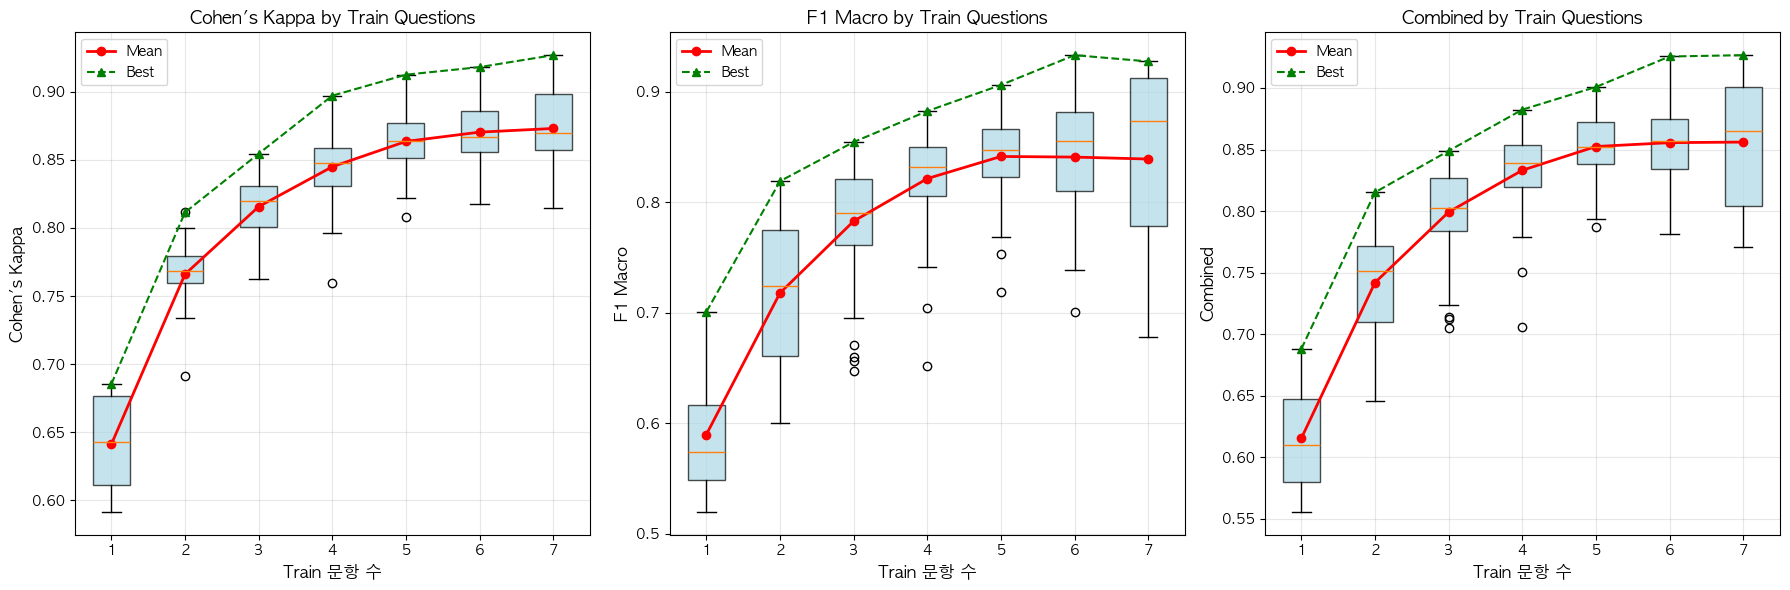

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (metric, label) in enumerate([('Test_Kappa', 'Cohen\'s Kappa'), ('Test_F1', 'F1 Macro'), ('Combined', 'Combined')]):
    ax = axes[idx]
    data_by_k = [qc_df[qc_df['N_Train_Qs']==k][metric].values for k in range(1,8)]
    bp = ax.boxplot(data_by_k, labels=range(1,8), patch_artist=True,
                    boxprops=dict(facecolor='lightblue', alpha=0.7))
    
    means = [qc_df[qc_df['N_Train_Qs']==k][metric].mean() for k in range(1,8)]
    bests = [qc_df[qc_df['N_Train_Qs']==k][metric].max() for k in range(1,8)]
    ax.plot(range(1,8), means, 'r-o', linewidth=2, markersize=6, label='Mean')
    ax.plot(range(1,8), bests, 'g--^', linewidth=1.5, markersize=6, label='Best')
    
    ax.set_xlabel('Train 문항 수', fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    ax.set_title(f'{label} by Train Questions', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig1_performance_by_nq.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.4 Same-Form vs Cross-Form 효과

### Same-Form vs Cross-Form 시각화

A형 문항으로만 학습 → B형 테스트(Cross-Form) vs
혼합 학습 → 혼합 테스트의 성능 차이를 시각화합니다.

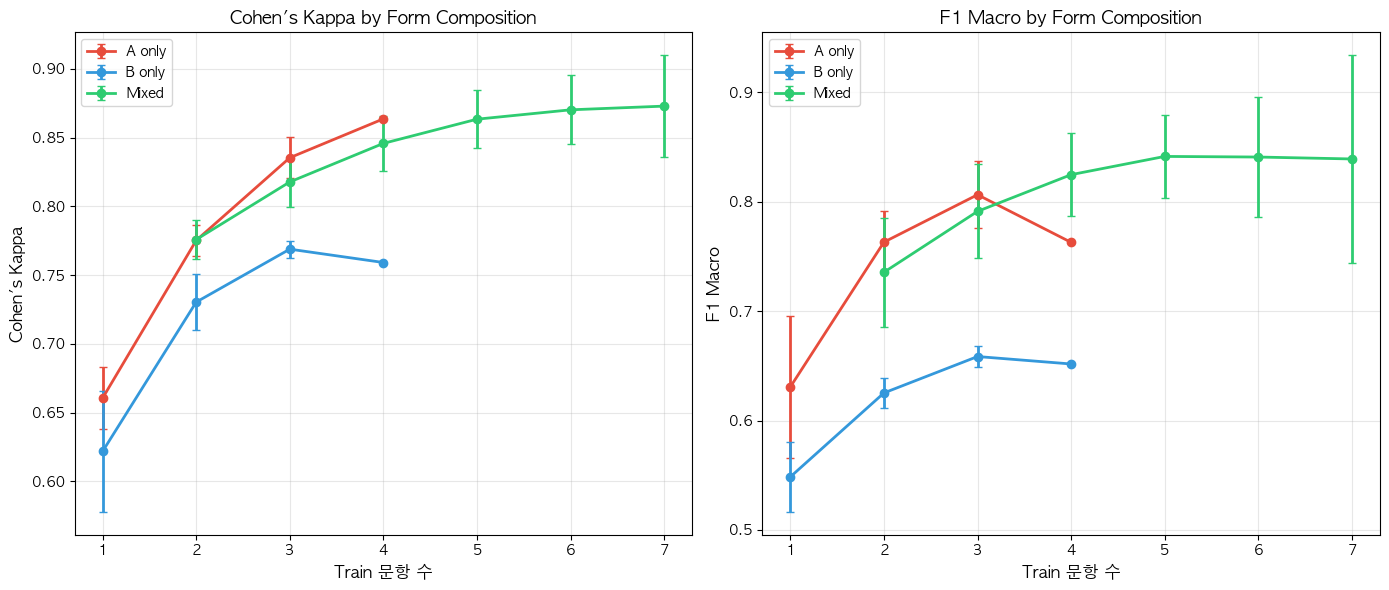

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = {'A only': '#e74c3c', 'B only': '#3498db', 'Mixed': '#2ecc71'}

for idx, (metric, label) in enumerate([('Test_Kappa', 'Cohen\'s Kappa'), ('Test_F1', 'F1 Macro')]):
    ax = axes[idx]
    for comp in ['A only', 'B only', 'Mixed']:
        subset = qc_df[qc_df['Form_Comp'] == comp]
        if len(subset) == 0:
            continue
        means = subset.groupby('N_Train_Qs')[metric].mean()
        stds = subset.groupby('N_Train_Qs')[metric].std()
        ax.errorbar(means.index, means.values, yerr=stds.values,
                    fmt='o-', label=comp, color=colors[comp], linewidth=2, capsize=3)
    
    ax.set_xlabel('Train 문항 수', fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    ax.set_title(f'{label} by Form Composition', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig2_form_composition.png', dpi=150, bbox_inches='tight')
plt.show()

### Form 구성별 상세 통계

A형(Q1~Q4)만, B형(Q5~Q8)만, 혼합(Mixed)으로 나누어 성능을 비교합니다.
같은 문항 수에서도 Form 구성에 따라 성능 차이가 있는지 확인합니다.

In [11]:
# Form 구성별 통계
print('=== Form 구성별 평균 성능 ===')
form_stats = qc_df.groupby(['N_Train_Qs', 'Form_Comp']).agg({
    'Test_Kappa': ['mean', 'std', 'count'],
    'Test_F1': ['mean', 'std']
}).round(4)
form_stats.columns = ['Kappa_Mean', 'Kappa_Std', 'N', 'F1_Mean', 'F1_Std']
display(form_stats)

=== Form 구성별 평균 성능 ===


Kappa_Mean  Kappa_Std   N  F1_Mean  F1_Std
N_Train_Qs Form_Comp                                            
1          A only         0.6606     0.0226   4   0.6308  0.0652
           B only         0.6218     0.0440   4   0.5486  0.0320
2          A only         0.7753     0.0111   6   0.7631  0.0284
           B only         0.7304     0.0203   6   0.6253  0.0137
           Mixed          0.7759     0.0142  16   0.7356  0.0499
3          A only         0.8354     0.0149   4   0.8064  0.0309
           B only         0.7689     0.0062   4   0.6585  0.0097
           Mixed          0.8178     0.0182  48   0.7912  0.0430
4          A only         0.8637        NaN   1   0.7629     NaN
           B only         0.7592        NaN   1   0.6517     NaN
           Mixed          0.8459     0.0202  68   0.8248  0.0377
5          Mixed          0.8635     0.0210  56   0.8414  0.0382
6          Mixed          0.8703     0.0251  28   0.8409  0.0545
7          Mixed          0.8730     0.0371   8   0.8391  0.0949

### 2.5 문항별 독립 예측력 (1문항 Train)

### 단일 문항 예측력 분석

1개 문항의 피드백만으로 학습한 모델이 나머지 7개 문항의 피드백을 
얼마나 잘 분류하는지 확인합니다. 높은 성능의 문항은 범용적인 피드백 패턴을 포함합니다.

=== 문항별 독립 예측력 (1문항으로 나머지 7문항 예측) ===
    문항   Form  Train_N   Test_N   CV_Kappa   Test_Kappa    Test_F1
----------------------------------------------------------------------
    Q6      B      255     1825     0.7354       0.6854     0.5906
    Q1      A      265     1815     0.7639       0.6816     0.6670
    Q2      A      265     1815     0.7641       0.6753     0.7007
    Q3      A      265     1815     0.8154       0.6534     0.5991
    Q4      A      265     1815     0.6997       0.6319     0.5564
    Q7      B      255     1825     0.7395       0.6175     0.5559
    Q8      B      255     1825     0.7422       0.5928     0.5281
    Q5      B      255     1825     0.7052       0.5916     0.5197


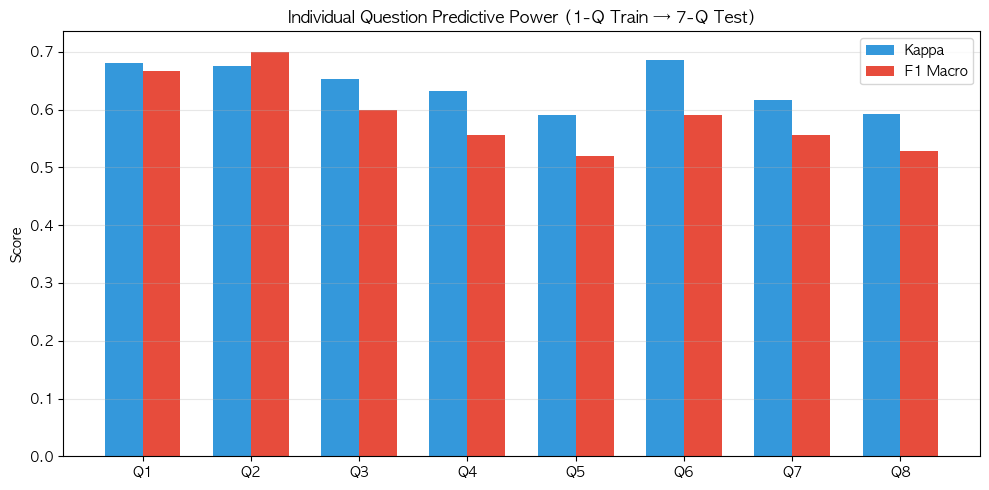

In [12]:
one_q = qc_df[qc_df['N_Train_Qs'] == 1].sort_values('Test_Kappa', ascending=False)

print('=== 문항별 독립 예측력 (1문항으로 나머지 7문항 예측) ===')
print(f'{"문항":>6} {"Form":>6} {"Train_N":>8} {"Test_N":>8} {"CV_Kappa":>10} {"Test_Kappa":>12} {"Test_F1":>10}')
print('-' * 70)
for _, row in one_q.iterrows():
    form = 'A' if row['Combo'] in ['Q1','Q2','Q3','Q4'] else 'B'
    print(f"{row['Combo']:>6} {form:>6} {row['Train_N']:>8} {row['Test_N']:>8} "
          f"{row['CV_Kappa']:>10.4f} {row['Test_Kappa']:>12.4f} {row['Test_F1']:>10.4f}")

# 시각화
fig, ax = plt.subplots(figsize=(10, 5))
q_order = one_q.sort_values('Combo')['Combo'].tolist()
kappas = [one_q[one_q['Combo']==q]['Test_Kappa'].values[0] for q in q_order]
f1s = [one_q[one_q['Combo']==q]['Test_F1'].values[0] for q in q_order]
x = np.arange(len(q_order))
width = 0.35
ax.bar(x - width/2, kappas, width, label='Kappa', color='#3498db')
ax.bar(x + width/2, f1s, width, label='F1 Macro', color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(q_order)
ax.set_ylabel('Score')
ax.set_title('Individual Question Predictive Power (1-Q Train → 7-Q Test)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig3_single_question_power.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.6 문항별 기여도 (7문항 Train, Leave-One-Out)

### Leave-One-Out 분석 (7문항 학습)

7개 문항으로 학습하고 나머지 1개 문항을 테스트합니다.
테스트 성능이 낮은 문항 = 다른 문항과 특성이 다른 문항으로 해석할 수 있습니다.

=== 7문항 Train 결과 (각 행 = 제외된 1문항이 Test) ===
     제외 문항                       Train_Qs   CV_Kappa   Test_Kappa    Test_F1
--------------------------------------------------------------------------------
        Q8           Q1,Q2,Q3,Q4,Q5,Q6,Q7     0.9171       0.8747     0.7324
        Q7           Q1,Q2,Q3,Q4,Q5,Q6,Q8     0.9220       0.9089     0.9275
        Q6           Q1,Q2,Q3,Q4,Q5,Q7,Q8     0.9261       0.9268     0.9265
        Q5           Q1,Q2,Q3,Q4,Q6,Q7,Q8     0.9264       0.8643     0.6776
        Q4           Q1,Q2,Q3,Q5,Q6,Q7,Q8     0.9260       0.8147     0.7941
        Q3           Q1,Q2,Q4,Q5,Q6,Q7,Q8     0.9166       0.8350     0.8514
        Q2           Q1,Q3,Q4,Q5,Q6,Q7,Q8     0.9289       0.8943     0.8959
        Q1           Q2,Q3,Q4,Q5,Q6,Q7,Q8     0.9328       0.8651     0.9075


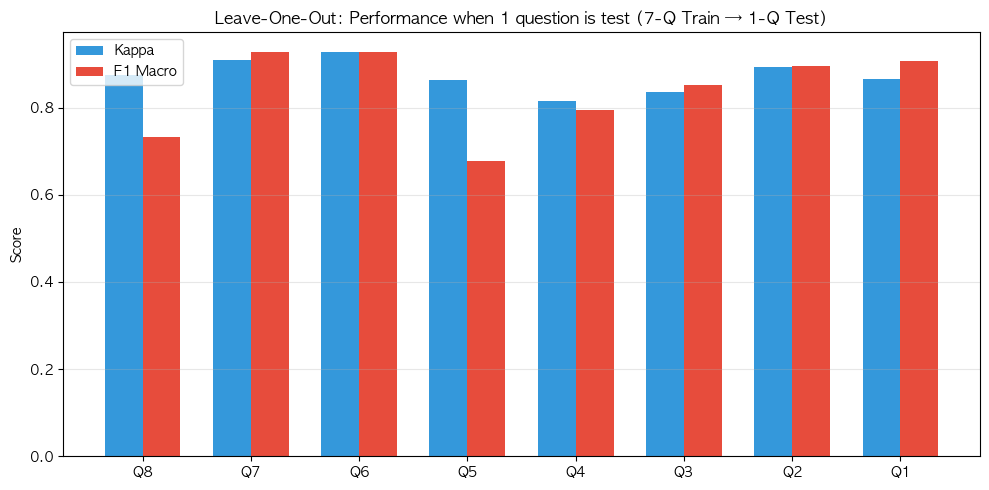

In [13]:
seven_q = qc_df[qc_df['N_Train_Qs'] == 7].copy()

print('=== 7문항 Train 결과 (각 행 = 제외된 1문항이 Test) ===')
print(f'{"제외 문항":>10} {"Train_Qs":>30} {"CV_Kappa":>10} {"Test_Kappa":>12} {"Test_F1":>10}')
print('-' * 80)
for _, row in seven_q.sort_values('Combo').iterrows():
    excluded = row['Test_Qs']
    print(f"{excluded:>10} {row['Train_Qs']:>30} {row['CV_Kappa']:>10.4f} {row['Test_Kappa']:>12.4f} {row['Test_F1']:>10.4f}")

# 시각화
fig, ax = plt.subplots(figsize=(10, 5))
loo = seven_q.sort_values('Combo')
excluded_qs = loo['Test_Qs'].tolist()
kappas = loo['Test_Kappa'].tolist()
f1s = loo['Test_F1'].tolist()
x = np.arange(len(excluded_qs))
width = 0.35
ax.bar(x - width/2, kappas, width, label='Kappa', color='#3498db')
ax.bar(x + width/2, f1s, width, label='F1 Macro', color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(excluded_qs)
ax.set_ylabel('Score')
ax.set_title('Leave-One-Out: Performance when 1 question is test (7-Q Train → 1-Q Test)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig4_leave_one_out.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.7 문항 수별 최적 조합

### 문항 수(k)별 최적 조합

각 문항 수(1~7)에서 가장 높은 Test Kappa를 달성한 조합을 보여줍니다.
이를 통해 특정 문항 수 제약 하에서의 최선의 선택을 파악합니다.

In [14]:
print('=== 문항 수별 최적 조합 (Test Kappa 기준) ===\n')
print(f'{"k":>3} {"조합":>25} {"Form":>8} {"CV_Kappa":>10} {"Test_Kappa":>12} {"Test_F1":>10} {"Combined":>10}')
print('-' * 85)

best_per_k = []
for k in range(1, 8):
    subset = qc_df[qc_df['N_Train_Qs'] == k]
    best = subset.loc[subset['Test_Kappa'].idxmax()]
    best_per_k.append(best)
    print(f"{k:>3} {best['Combo']:>25} {best['Form_Comp']:>8} "
          f"{best['CV_Kappa']:>10.4f} {best['Test_Kappa']:>12.4f} {best['Test_F1']:>10.4f} {best['Combined']:>10.4f}")

# 같은 분석을 Combined 기준으로
print(f'\n=== 문항 수별 최적 조합 (Combined 기준) ===\n')
print(f'{"k":>3} {"조합":>25} {"Form":>8} {"CV_Kappa":>10} {"Test_Kappa":>12} {"Test_F1":>10} {"Combined":>10}')
print('-' * 85)
for k in range(1, 8):
    subset = qc_df[qc_df['N_Train_Qs'] == k]
    best = subset.loc[subset['Combined'].idxmax()]
    print(f"{k:>3} {best['Combo']:>25} {best['Form_Comp']:>8} "
          f"{best['CV_Kappa']:>10.4f} {best['Test_Kappa']:>12.4f} {best['Test_F1']:>10.4f} {best['Combined']:>10.4f}")

=== 문항 수별 최적 조합 (Test Kappa 기준) ===

  k                        조합     Form   CV_Kappa   Test_Kappa    Test_F1   Combined
-------------------------------------------------------------------------------------
  1                        Q6   B only     0.7354       0.6854     0.5906     0.6380
  2                     Q2_Q5    Mixed     0.8117       0.8114     0.8190     0.8152
  3                  Q1_Q4_Q5    Mixed     0.8503       0.8544     0.8324     0.8434
  4               Q1_Q3_Q4_Q5    Mixed     0.8938       0.8970     0.8677     0.8824
  5            Q1_Q3_Q4_Q5_Q8    Mixed     0.9033       0.9125     0.8891     0.9008
  6         Q1_Q2_Q3_Q4_Q5_Q8    Mixed     0.9149       0.9180     0.9331     0.9256
  7      Q1_Q2_Q3_Q4_Q5_Q7_Q8    Mixed     0.9261       0.9268     0.9265     0.9266

=== 문항 수별 최적 조합 (Combined 기준) ===

  k                        조합     Form   CV_Kappa   Test_Kappa    Test_F1   Combined
----------------------------------------------------------------------------

### 2.8 CV 성능과 Test 성능의 관계

### CV 성능과 Test 성능의 산점도

CV 성능이 높은 조합이 실제 Test에서도 높은 성능을 보이는지 확인합니다.
대각선에 가까울수록 CV가 Test 성능의 좋은 예측 지표임을 의미합니다.
Form 구성(A only/B only/Mixed)별로 색상을 구분합니다.

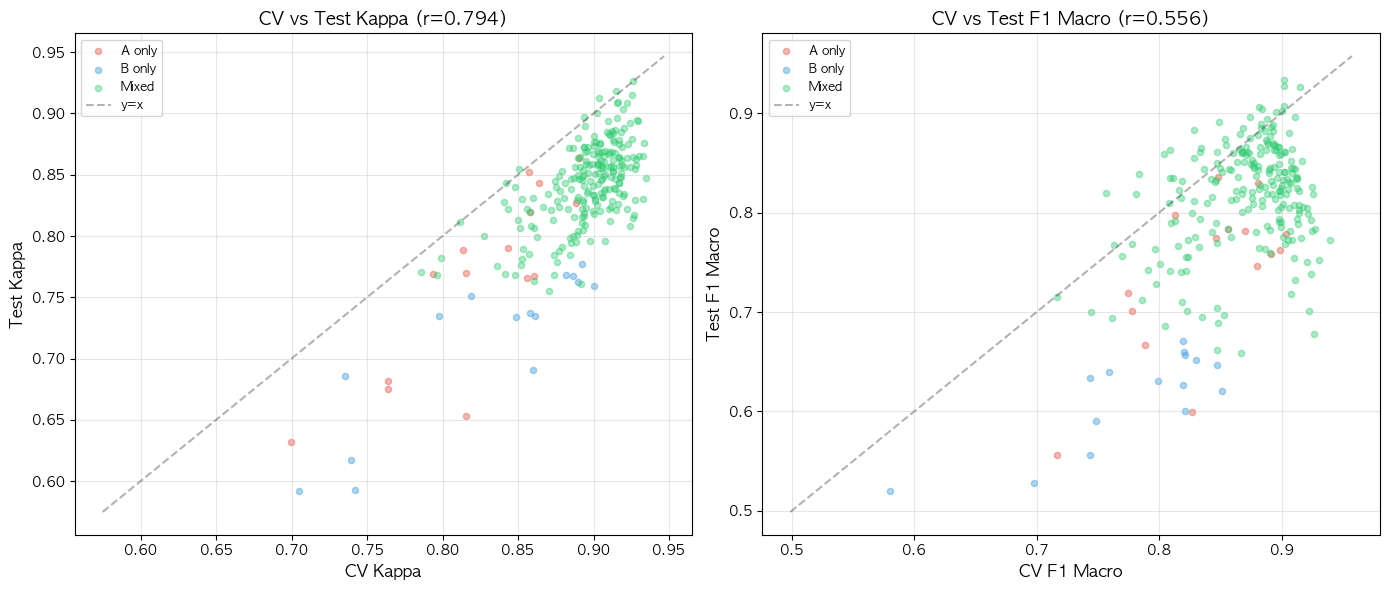

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (cv_col, test_col, label) in enumerate([
    ('CV_Kappa', 'Test_Kappa', 'Kappa'),
    ('CV_F1', 'Test_F1', 'F1 Macro')
]):
    ax = axes[idx]
    colors_map = {'A only': '#e74c3c', 'B only': '#3498db', 'Mixed': '#2ecc71'}
    for comp in ['A only', 'B only', 'Mixed']:
        subset = qc_df[qc_df['Form_Comp'] == comp]
        ax.scatter(subset[cv_col], subset[test_col], alpha=0.4, s=20,
                   color=colors_map[comp], label=comp)
    
    # Diagonal line
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'k--', alpha=0.3, label='y=x')
    
    # Correlation
    corr = qc_df[cv_col].corr(qc_df[test_col])
    ax.set_xlabel(f'CV {label}', fontsize=12)
    ax.set_ylabel(f'Test {label}', fontsize=12)
    ax.set_title(f'CV vs Test {label} (r={corr:.3f})', fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig5_cv_vs_test.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. 학생 분할 실험 분석

### 학생 분할 결과 개요

15개 분할(5비율 × 3seed)의 전체 결과를 표시합니다.
Combined 점수 = (Kappa + F1) / 2 로 종합 성능을 요약합니다.

In [16]:
ss_df['Combined'] = (ss_df['Test_Kappa'] + ss_df['Test_F1']) / 2

print('=== 학생 분할 전체 결과 ===')
display(ss_df[['Split', 'Ratio', 'Seed', 'Train_N', 'Test_N',
               'CV_F1', 'CV_Kappa', 'Test_F1', 'Test_Kappa', 'Combined',
               'Time_Seconds']].sort_values(['Ratio', 'Seed']))

=== 학생 분할 전체 결과 ===


,Split,Ratio,Seed,Train_N,Test_N,CV_F1,CV_Kappa,Test_F1,Test_Kappa,Combined,Time_Seconds
1,40:60_seed42,40:60,42,860,1220,0.893154,0.889054,0.722722,0.803851,0.763286,188.2
0,40:60_seed123,40:60,123,800,1280,0.860828,0.881135,0.708400,0.724493,0.716446,181.8
2,40:60_seed456,40:60,456,860,1220,0.871114,0.879881,0.666612,0.767259,0.716936,188.2
4,50:50_seed42,50:50,42,1040,1040,0.900941,0.907917,0.693362,0.842978,0.768170,215.1
3,50:50_seed123,50:50,123,1000,1080,0.831328,0.884932,0.736023,0.767584,0.751804,217.7
5,50:50_seed456,50:50,456,1040,1040,0.890163,0.903674,0.792398,0.799307,0.795853,213.6
7,60:40_seed42,60:40,42,1280,800,0.901373,0.917312,0.693602,0.823989,0.758795,253.9
6,60:40_seed123,60:40,123,1220,860,0.884583,0.905951,0.808273,0.844152,0.826212,241.3
8,60:40_seed456,60:40,456,1260,820,0.906652,0.908600,0.851562,0.845238,0.848400,247.1
10,70:30_seed42,70:30,42,1440,640,0.904672,0.921646,0.691914,0.864806,0.778360,274.7


### 3.1 비율별 성능 추이

### 비율별 성능 통계

5개 비율(80:20~40:60)에서의 평균 성능을 계산합니다.
학습 데이터가 줄어들수록 성능이 얼마나 하락하는지 정량적으로 확인합니다.

In [17]:
# 비율별 평균 (3 seed 평균)
ratio_order = ['80:20', '70:30', '60:40', '50:50', '40:60']
ratio_stats = ss_df.groupby('Ratio').agg({
    'Test_Kappa': ['mean', 'std'],
    'Test_F1': ['mean', 'std'],
    'CV_Kappa': ['mean', 'std'],
    'CV_F1': ['mean', 'std'],
    'Combined': ['mean'],
    'Train_N': 'mean',
    'Test_N': 'mean'
}).round(4)
ratio_stats.columns = ['Test_Kappa_Mean', 'Test_Kappa_Std',
                        'Test_F1_Mean', 'Test_F1_Std',
                        'CV_Kappa_Mean', 'CV_Kappa_Std',
                        'CV_F1_Mean', 'CV_F1_Std',
                        'Combined_Mean', 'Avg_Train_N', 'Avg_Test_N']
ratio_stats = ratio_stats.reindex(ratio_order)

print('=== 비율별 평균 성능 (3 seed 평균 ± std) ===')
display(ratio_stats)

=== 비율별 평균 성능 (3 seed 평균 ± std) ===


,Test_Kappa_Mean,Test_Kappa_Std,Test_F1_Mean,Test_F1_Std,CV_Kappa_Mean,CV_Kappa_Std,CV_F1_Mean,CV_F1_Std,Combined_Mean,Avg_Train_N,Avg_Test_N
Ratio,,,,,,,,,,,
80:20,0.8685,0.0313,0.8308,0.0581,0.9259,0.0046,0.9175,0.0080,0.8496,1673.3333,406.6667
70:30,0.8652,0.0109,0.7884,0.0932,0.9200,0.0017,0.9129,0.0090,0.8268,1440.0000,640.0000
60:40,0.8378,0.0120,0.7845,0.0816,0.9106,0.0059,0.8975,0.0115,0.8111,1253.3333,826.6667
50:50,0.8033,0.0379,0.7406,0.0497,0.8988,0.0122,0.8741,0.0375,0.7719,1026.6667,1053.3333
40:60,0.7652,0.0397,0.6992,0.0292,0.8834,0.0050,0.8750,0.0165,0.7322,840.0000,1240.0000


### 학생 비율별 성능 추이 시각화

학습 데이터 비율(80%→40%)에 따른 Kappa, F1, Accuracy 변화를 시각화합니다.
3개 seed의 평균과 표준편차를 함께 표시합니다.

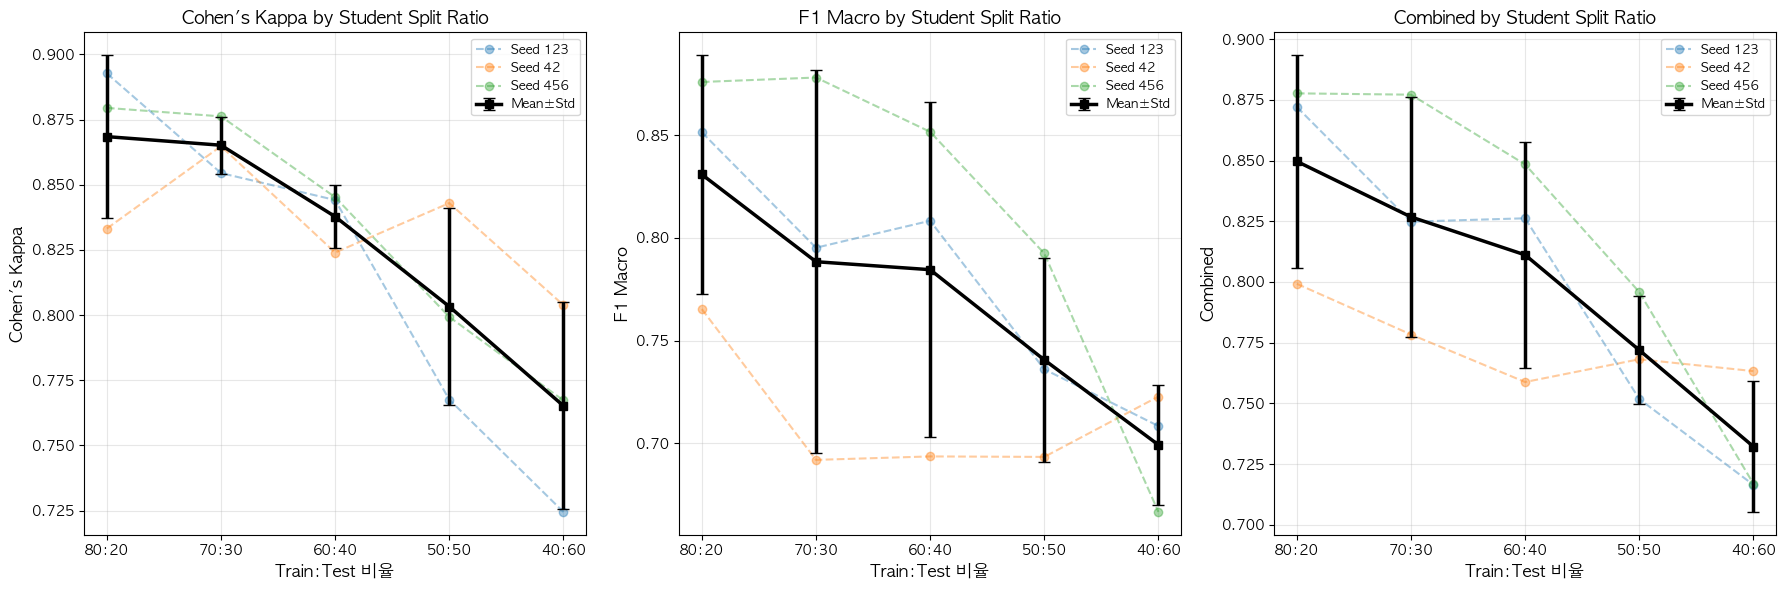

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (metric, label) in enumerate([('Test_Kappa', 'Cohen\'s Kappa'), ('Test_F1', 'F1 Macro'), ('Combined', 'Combined')]):
    ax = axes[idx]
    
    # Individual seed points
    for seed in ss_df['Seed'].unique():
        seed_data = ss_df[ss_df['Seed'] == seed].set_index('Ratio').reindex(ratio_order)
        ax.plot(range(len(ratio_order)), seed_data[metric].values,
                'o--', alpha=0.4, label=f'Seed {seed}')
    
    # Mean line
    means = ss_df.groupby('Ratio')[metric].mean().reindex(ratio_order)
    stds = ss_df.groupby('Ratio')[metric].std().reindex(ratio_order)
    ax.errorbar(range(len(ratio_order)), means.values, yerr=stds.values,
                fmt='s-', color='black', linewidth=2.5, capsize=4, label='Mean±Std', zorder=5)
    
    ax.set_xticks(range(len(ratio_order)))
    ax.set_xticklabels(ratio_order)
    ax.set_xlabel('Train:Test 비율', fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    ax.set_title(f'{label} by Student Split Ratio', fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig6_student_split_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Seed간 안정성

### Seed간 안정성 분석

같은 비율에서 3개 seed의 성능 편차를 확인합니다.
편차가 작을수록 모델이 특정 학생 조합에 의존하지 않고 안정적입니다.

In [19]:
print('=== Seed간 성능 편차 (비율별) ===')
for ratio in ratio_order:
    subset = ss_df[ss_df['Ratio'] == ratio]
    kappas = subset['Test_Kappa'].values
    f1s = subset['Test_F1'].values
    print(f'\n[{ratio}] (n={len(subset)})')
    print(f'  Kappa: {kappas.mean():.4f} ± {kappas.std():.4f}  (range: {kappas.min():.4f} ~ {kappas.max():.4f})')
    print(f'  F1:    {f1s.mean():.4f} ± {f1s.std():.4f}  (range: {f1s.min():.4f} ~ {f1s.max():.4f})')

=== Seed간 성능 편차 (비율별) ===

[80:20] (n=3)
  Kappa: 0.8685 ± 0.0255  (range: 0.8332 ~ 0.8927)
  F1:    0.8308 ± 0.0474  (range: 0.7653 ~ 0.8758)

[70:30] (n=3)
  Kappa: 0.8652 ± 0.0089  (range: 0.8545 ~ 0.8762)
  F1:    0.7884 ± 0.0761  (range: 0.6919 ~ 0.8780)

[60:40] (n=3)
  Kappa: 0.8378 ± 0.0098  (range: 0.8240 ~ 0.8452)
  F1:    0.7845 ± 0.0666  (range: 0.6936 ~ 0.8516)

[50:50] (n=3)
  Kappa: 0.8033 ± 0.0309  (range: 0.7676 ~ 0.8430)
  F1:    0.7406 ± 0.0406  (range: 0.6934 ~ 0.7924)

[40:60] (n=3)
  Kappa: 0.7652 ± 0.0324  (range: 0.7245 ~ 0.8039)
  F1:    0.6992 ± 0.0238  (range: 0.6666 ~ 0.7227)


### 3.3 CV vs Test 괴리 (Overfitting 진단)

### 과적합(Overfitting) 진단

CV 성능과 Test 성능의 차이(Gap)를 분석합니다.
- Gap이 양수: CV 성능 > Test 성능 → 과적합 경향
- Gap이 클수록: 학습 데이터에만 맞춰지고 새로운 데이터에 일반화되지 않음
- 학습 데이터가 적을수록(40:60) 과적합 위험이 커질 수 있습니다.

=== CV-Test 성능 괴리 (양수 = CV가 높음 = overfitting 경향) ===


,Kappa_Gap_Mean,Kappa_Gap_Std,F1_Gap_Mean,F1_Gap_Std
Ratio,,,,
80:20,0.0574,0.0346,0.0867,0.0589
70:30,0.0549,0.0120,0.1246,0.0844
60:40,0.0728,0.0178,0.1131,0.0827
50:50,0.0956,0.0273,0.1335,0.0641
40:60,0.1182,0.0360,0.1758,0.0264


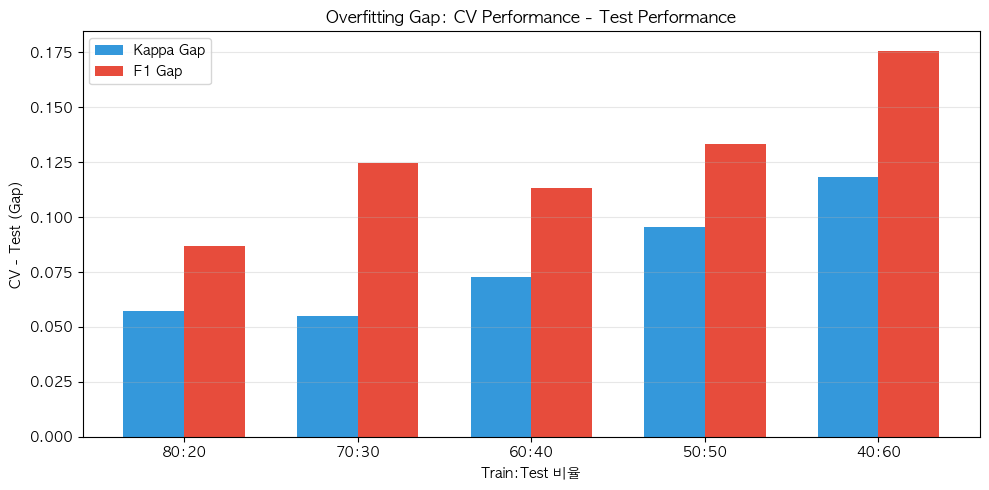

In [20]:
ss_df['Kappa_Gap'] = ss_df['CV_Kappa'] - ss_df['Test_Kappa']  # 양수 = CV가 높음 = 과적합 경향
ss_df['F1_Gap'] = ss_df['CV_F1'] - ss_df['Test_F1']  # F1에서의 CV-Test 괴리

print('=== CV-Test 성능 괴리 (양수 = CV가 높음 = overfitting 경향) ===')
gap_stats = ss_df.groupby('Ratio').agg({
    'Kappa_Gap': ['mean', 'std'],
    'F1_Gap': ['mean', 'std']
}).round(4).reindex(ratio_order)
gap_stats.columns = ['Kappa_Gap_Mean', 'Kappa_Gap_Std', 'F1_Gap_Mean', 'F1_Gap_Std']
display(gap_stats)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(ratio_order))
width = 0.35
kappa_gaps = gap_stats['Kappa_Gap_Mean'].values
f1_gaps = gap_stats['F1_Gap_Mean'].values
ax.bar(x - width/2, kappa_gaps, width, label='Kappa Gap', color='#3498db')
ax.bar(x + width/2, f1_gaps, width, label='F1 Gap', color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(ratio_order)
ax.set_xlabel('Train:Test 비율')
ax.set_ylabel('CV - Test (Gap)')
ax.set_title('Overfitting Gap: CV Performance - Test Performance')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig7_overfitting_gap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. 종합 요약

### 종합 요약 출력

문항 조합 실험과 학생 분할 실험의 핵심 결과를 요약합니다.
문항 수별 최적 성능, 학습 데이터 비율별 성능 변화, 최적 조합 등을 보고합니다.

In [21]:
print('=' * 90)
print('BERT 일반화 실험 종합 요약')
print('=' * 90)

# 문항 조합
print(f'\n[1] 문항 조합 실험 (254 조합, KLUE-BERT)')
print(f'    전체 평균 — Kappa: {qc_df["Test_Kappa"].mean():.4f}, F1: {qc_df["Test_F1"].mean():.4f}')
best_q = qc_df.loc[qc_df['Test_Kappa'].idxmax()]
print(f'    최고 성능 — {best_q["Combo"]} (Kappa: {best_q["Test_Kappa"]:.4f}, F1: {best_q["Test_F1"]:.4f})')

print(f'\n    문항 수별 평균 Kappa:')
for k in range(1, 8):
    mean_k = qc_df[qc_df['N_Train_Qs']==k]['Test_Kappa'].mean()
    max_k = qc_df[qc_df['N_Train_Qs']==k]['Test_Kappa'].max()
    best_combo = qc_df[qc_df['N_Train_Qs']==k].loc[qc_df[qc_df['N_Train_Qs']==k]['Test_Kappa'].idxmax(), 'Combo']
    print(f'      {k}문항: 평균 {mean_k:.4f}, 최고 {max_k:.4f} ({best_combo})')

# Form 효과
mixed_mean = qc_df[qc_df['Form_Comp']=='Mixed']['Test_Kappa'].mean()
same_mean = qc_df[qc_df['Form_Comp'].isin(['A only','B only'])]['Test_Kappa'].mean()
print(f'\n    Form 효과: Mixed 평균 Kappa {mixed_mean:.4f} vs Same-Form {same_mean:.4f}')

# 학생 분할
print(f'\n[2] 학생 분할 실험 (15 분할, KLUE-BERT)')
print(f'    전체 평균 — Kappa: {ss_df["Test_Kappa"].mean():.4f}, F1: {ss_df["Test_F1"].mean():.4f}')
best_s = ss_df.loc[ss_df['Test_Kappa'].idxmax()]
print(f'    최고 성능 — {best_s["Ratio"]} seed{best_s["Seed"]} (Kappa: {best_s["Test_Kappa"]:.4f}, F1: {best_s["Test_F1"]:.4f})')

print(f'\n    비율별 평균 Kappa:')
for ratio in ratio_order:
    subset = ss_df[ss_df['Ratio']==ratio]
    print(f'      {ratio}: {subset["Test_Kappa"].mean():.4f} ± {subset["Test_Kappa"].std():.4f}')

# 총 소요시간
total_q_time = qc_df['Time_Seconds'].sum() / 3600
total_s_time = ss_df['Time_Seconds'].sum() / 3600
print(f'\n[3] 총 소요시간')
print(f'    문항 조합: {total_q_time:.1f}시간')
print(f'    학생 분할: {total_s_time:.1f}시간')
print(f'    합계: {total_q_time + total_s_time:.1f}시간')

print(f'\n{"="*90}')

BERT 일반화 실험 종합 요약

[1] 문항 조합 실험 (254 조합, KLUE-BERT)
    전체 평균 — Kappa: 0.8311, F1: 0.8013
    최고 성능 — Q1_Q2_Q3_Q4_Q5_Q7_Q8 (Kappa: 0.9268, F1: 0.9265)

    문항 수별 평균 Kappa:
      1문항: 평균 0.6412, 최고 0.6854 (Q6)
      2문항: 평균 0.7660, 최고 0.8114 (Q2_Q5)
      3문항: 평균 0.8156, 최고 0.8544 (Q1_Q4_Q5)
      4문항: 평균 0.8449, 최고 0.8970 (Q1_Q3_Q4_Q5)
      5문항: 평균 0.8635, 최고 0.9125 (Q1_Q3_Q4_Q5_Q8)
      6문항: 평균 0.8703, 최고 0.9180 (Q1_Q2_Q3_Q4_Q5_Q8)
      7문항: 평균 0.8730, 최고 0.9268 (Q1_Q2_Q3_Q4_Q5_Q7_Q8)

    Form 효과: Mixed 평균 Kappa 0.8433 vs Same-Form 0.7401

[2] 학생 분할 실험 (15 분할, KLUE-BERT)
    전체 평균 — Kappa: 0.8280, F1: 0.7687
    최고 성능 — 80:20 seed123 (Kappa: 0.8927, F1: 0.8513)

    비율별 평균 Kappa:
      80:20: 0.8685 ± 0.0313
      70:30: 0.8652 ± 0.0109
      60:40: 0.8378 ± 0.0120
      50:50: 0.8033 ± 0.0379
      40:60: 0.7652 ± 0.0397

[3] 총 소요시간
    문항 조합: 15.5시간
    학생 분할: 1.0시간
    합계: 16.5시간



---
## 5. A형 ↔ B형 전이 가능성 분석

Q1-Q4 (A형)과 Q5-Q8 (B형) 간의 교차 전이 성능을 분석합니다.

1. **A→B 전이**: A형 4문항으로 학습 → B형 4문항 예측
2. **B→A 전이**: B형 4문항으로 학습 → A형 4문항 예측
3. **Mixed 4문항 대비**: 동일 문항 수(4개) 혼합 조합과 비교

### A형/B형 교차 전이 분석 코드

Q1~Q4(A형 시험지)로만 학습한 모델이 Q5~Q8(B형 시험지)의 피드백도 분류할 수 있는지,
그 반대도 가능한지 분석합니다. 혼합(Mixed) 조합과 비교하여 전이 학습의 효과를 확인합니다.

A형 ↔ B형 전이 성능 (KLUE-BERT, 4:4 문항 분할)


,Direction,Train_Qs,Test_Qs,Train_N,Test_N,CV_Kappa,CV_F1,Test_Kappa,Test_F1,Test_Accuracy,Combined,Mixed4q_Mean_Kappa,Mixed4q_Best_Kappa,Mixed4q_Mean_F1,Mixed4q_Best_F1,Kappa_Percentile_in_Mixed4q,F1_Percentile_in_Mixed4q
0,A→B,"Q1,Q2,Q3,Q4","Q5,Q6,Q7,Q8",1060,1020,0.8904,0.8989,0.8637,0.7629,0.9000,0.8133,0.8459,0.897,0.8248,0.8825,80.8824,8.8235
1,B→A,"Q5,Q6,Q7,Q8","Q1,Q2,Q3,Q4",1020,1060,0.9004,0.8305,0.7592,0.6517,0.8151,0.7055,0.8459,0.897,0.8248,0.8825,0.0000,0.0000



--- Mixed 4문항 조합 통계 (비교 기준, n=68) ---
  Kappa: 평균 0.8459, 최고 0.8970, 최저 0.7959
  F1:    평균 0.8248, 최고 0.8825, 최저 0.7043

  A only (4문항 전체): Kappa=0.8637, F1=0.7629
  B only (4문항 전체): Kappa=0.7592, F1=0.6517


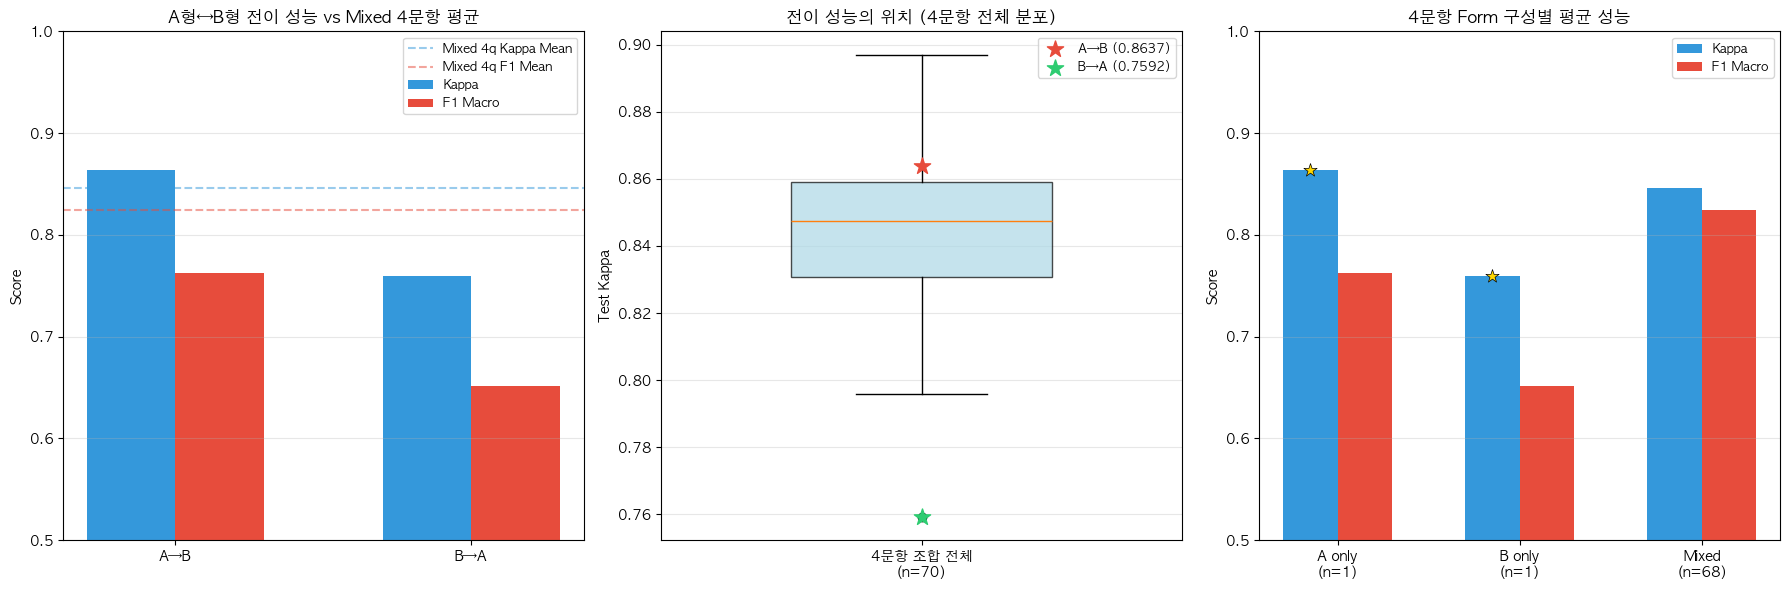

저장: bert_analysis/fig8_form_transfer.png
저장: bert_analysis/bert_form_transfer_analysis.csv

해석 요약

  [A→B] Kappa=0.8637, F1=0.7629 (Mixed 4문항 중 하위 80.9%ile)

  [B→A] Kappa=0.7592, F1=0.6517 (Mixed 4문항 중 하위 0.0%ile)

  방향 차이: Kappa 0.1045, F1 0.1111 (A→B가 더 높음)
  Mixed 4문항 평균 대비 A→B: Kappa +0.0178
  Mixed 4문항 평균 대비 B→A: Kappa -0.0867


In [22]:
# =========================
# A형 ↔ B형 전이 가능성 분석
# =========================
Q_A = {'Q1', 'Q2', 'Q3', 'Q4'}  # A형 시험지 문항
Q_B = {'Q5', 'Q6', 'Q7', 'Q8'}  # B형 시험지 문항

def to_qset(qs_text):
    if pd.isna(qs_text):
        return set()
    return set(q.strip() for q in str(qs_text).split(',') if q.strip())

qc_tf = qc_df.copy()
qc_tf['Train_Qs_Set'] = qc_tf['Train_Qs'].apply(to_qset)
qc_tf['Test_Qs_Set'] = qc_tf['Test_Qs'].apply(to_qset)

# --- 1) A→B, B→A 전이 성능 ---
directions = [
    ('A→B', Q_A, Q_B),
    ('B→A', Q_B, Q_A),
]

rq_rows = []
for name, train_set, test_set in directions:
    subset = qc_tf[
        qc_tf['Train_Qs_Set'].apply(lambda s: s == train_set)
        & qc_tf['Test_Qs_Set'].apply(lambda s: s == test_set)
    ]
    if subset.empty:
        print(f'{name}: 해당 조건 데이터 없음')
        continue
    row = subset.iloc[0]
    rq_rows.append({
        'Direction': name,
        'Train_Qs': ','.join(sorted(train_set)),
        'Test_Qs': ','.join(sorted(test_set)),
        'Train_N': int(row['Train_N']),
        'Test_N': int(row['Test_N']),
        'CV_Kappa': float(row['CV_Kappa']),
        'CV_F1': float(row['CV_F1']),
        'Test_Kappa': float(row['Test_Kappa']),
        'Test_F1': float(row['Test_F1']),
        'Test_Accuracy': float(row['Test_Accuracy']),
        'Combined': float(row['Combined']),
    })

transfer_df = pd.DataFrame(rq_rows)

# --- 2) Mixed 4문항 조합 대비 ---
four_q = qc_tf[qc_tf['N_Train_Qs'] == 4].copy()
mixed_4q = four_q[four_q['Form_Comp'] == 'Mixed']

if not transfer_df.empty and not mixed_4q.empty:
    transfer_df['Mixed4q_Mean_Kappa'] = float(mixed_4q['Test_Kappa'].mean())
    transfer_df['Mixed4q_Best_Kappa'] = float(mixed_4q['Test_Kappa'].max())
    transfer_df['Mixed4q_Mean_F1'] = float(mixed_4q['Test_F1'].mean())
    transfer_df['Mixed4q_Best_F1'] = float(mixed_4q['Test_F1'].max())
    # Percentile: 이 전이 성능이 Mixed 4문항 중 어디에 위치하는지
    transfer_df['Kappa_Percentile_in_Mixed4q'] = transfer_df['Test_Kappa'].apply(
        lambda v: float((mixed_4q['Test_Kappa'] <= v).mean() * 100))
    transfer_df['F1_Percentile_in_Mixed4q'] = transfer_df['Test_F1'].apply(
        lambda v: float((mixed_4q['Test_F1'] <= v).mean() * 100))

# --- 3) 출력 ---
print('=' * 100)
print('A형 ↔ B형 전이 성능 (KLUE-BERT, 4:4 문항 분할)')
print('=' * 100)
if transfer_df.empty:
    print('전이 조건 데이터를 찾을 수 없습니다.')
else:
    display(transfer_df.round(4))

    print(f'\n--- Mixed 4문항 조합 통계 (비교 기준, n={len(mixed_4q)}) ---')
    print(f"  Kappa: 평균 {mixed_4q['Test_Kappa'].mean():.4f}, "
          f"최고 {mixed_4q['Test_Kappa'].max():.4f}, "
          f"최저 {mixed_4q['Test_Kappa'].min():.4f}")
    print(f"  F1:    평균 {mixed_4q['Test_F1'].mean():.4f}, "
          f"최고 {mixed_4q['Test_F1'].max():.4f}, "
          f"최저 {mixed_4q['Test_F1'].min():.4f}")

    # A only, B only 평균도 비교
    a_only_4 = four_q[four_q['Form_Comp'] == 'A only']
    b_only_4 = four_q[four_q['Form_Comp'] == 'B only']
    if not a_only_4.empty:
        print(f"\n  A only (4문항 전체): Kappa={a_only_4['Test_Kappa'].mean():.4f}, F1={a_only_4['Test_F1'].mean():.4f}")
    if not b_only_4.empty:
        print(f"  B only (4문항 전체): Kappa={b_only_4['Test_Kappa'].mean():.4f}, F1={b_only_4['Test_F1'].mean():.4f}")

# --- 4) 시각화 ---
if not transfer_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # (a) 전이 방향별 Kappa & F1
    ax = axes[0]
    x = np.arange(len(transfer_df))
    width = 0.3
    ax.bar(x - width/2, transfer_df['Test_Kappa'], width, label='Kappa', color='#3498db')
    ax.bar(x + width/2, transfer_df['Test_F1'], width, label='F1 Macro', color='#e74c3c')
    if not mixed_4q.empty:
        ax.axhline(y=mixed_4q['Test_Kappa'].mean(), color='#3498db', linestyle='--', alpha=0.5, label=f'Mixed 4q Kappa Mean')
        ax.axhline(y=mixed_4q['Test_F1'].mean(), color='#e74c3c', linestyle='--', alpha=0.5, label=f'Mixed 4q F1 Mean')
    ax.set_xticks(x)
    ax.set_xticklabels(transfer_df['Direction'])
    ax.set_ylabel('Score')
    ax.set_title('A형↔B형 전이 성능 vs Mixed 4문항 평균')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0.5, 1.0)

    # (b) 4문항 조합 전체 분포에서 전이 성능 위치
    ax = axes[1]
    ax.boxplot([four_q['Test_Kappa'].values], positions=[1], widths=0.5,
               patch_artist=True, boxprops=dict(facecolor='lightblue', alpha=0.7))
    colors_dir = {'A→B': '#e74c3c', 'B→A': '#2ecc71'}
    for _, row in transfer_df.iterrows():
        ax.scatter(1, row['Test_Kappa'], s=150, zorder=5, marker='*',
                   color=colors_dir.get(row['Direction'], 'black'),
                   label=f"{row['Direction']} ({row['Test_Kappa']:.4f})")
    ax.set_xticks([1])
    ax.set_xticklabels(['4문항 조합 전체\n(n={})'.format(len(four_q))])
    ax.set_ylabel('Test Kappa')
    ax.set_title('전이 성능의 위치 (4문항 전체 분포)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

    # (c) Form 구성별 4문항 성능 비교
    ax = axes[2]
    form_groups = {'A only': a_only_4, 'B only': b_only_4, 'Mixed': mixed_4q}
    form_labels = []
    form_kappas = []
    form_f1s = []
    for fname, fdf in form_groups.items():
        if not fdf.empty:
            form_labels.append(f'{fname}\n(n={len(fdf)})')
            form_kappas.append(fdf['Test_Kappa'].mean())
            form_f1s.append(fdf['Test_F1'].mean())

    if form_labels:
        x = np.arange(len(form_labels))
        ax.bar(x - width/2, form_kappas, width, label='Kappa', color='#3498db')
        ax.bar(x + width/2, form_f1s, width, label='F1 Macro', color='#e74c3c')
        # 전이 성능 점으로 표시
        for _, row in transfer_df.iterrows():
            marker_x = 0 if 'A' in row['Direction'][:1] else 1
            ax.scatter(marker_x - width/2, row['Test_Kappa'], s=100, marker='*',
                       color='gold', zorder=5, edgecolors='black', linewidths=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels(form_labels)
        ax.set_ylabel('Score')
        ax.set_title('4문항 Form 구성별 평균 성능')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_ylim(0.5, 1.0)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig8_form_transfer.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'저장: {OUTPUT_DIR / "fig8_form_transfer.png"}')

# --- 5) 전이 결과 CSV 저장 ---
if not transfer_df.empty:
    transfer_csv = OUTPUT_DIR / 'bert_form_transfer_analysis.csv'
    transfer_df.to_csv(transfer_csv, index=False)
    print(f'저장: {transfer_csv}')

# --- 6) 해석 요약 ---
if not transfer_df.empty:
    print('\n' + '=' * 100)
    print('해석 요약')
    print('=' * 100)
    for _, row in transfer_df.iterrows():
        direction = row['Direction']
        kappa = row['Test_Kappa']
        f1 = row['Test_F1']
        pct_k = row.get('Kappa_Percentile_in_Mixed4q', None)
        print(f'\n  [{direction}] Kappa={kappa:.4f}, F1={f1:.4f}', end='')
        if pct_k is not None:
            print(f' (Mixed 4문항 중 하위 {pct_k:.1f}%ile)')
        else:
            print()

    if len(transfer_df) == 2:
        a2b = transfer_df[transfer_df['Direction'] == 'A→B'].iloc[0]
        b2a = transfer_df[transfer_df['Direction'] == 'B→A'].iloc[0]
        diff_k = a2b['Test_Kappa'] - b2a['Test_Kappa']
        diff_f1 = a2b['Test_F1'] - b2a['Test_F1']
        better = 'A→B' if diff_k > 0 else 'B→A'
        print(f'\n  방향 차이: Kappa {abs(diff_k):.4f}, F1 {abs(diff_f1):.4f} ({better}가 더 높음)')
        print(f'  Mixed 4문항 평균 대비 A→B: Kappa {a2b["Test_Kappa"] - mixed_4q["Test_Kappa"].mean():+.4f}')
        print(f'  Mixed 4문항 평균 대비 B→A: Kappa {b2a["Test_Kappa"] - mixed_4q["Test_Kappa"].mean():+.4f}')